Mounted at /content/drive
Analyzing traffic signs...

Sign #1:
  Vertices: fine=3, mid=3, coarse=3
  Circularity: 0.558
  Mean HSV: H=29.0, S=255.0, V=254.0
  Result: Shape=inverted_triangle, Color=yellow
  Classification: Yield (Construction)

Final result:


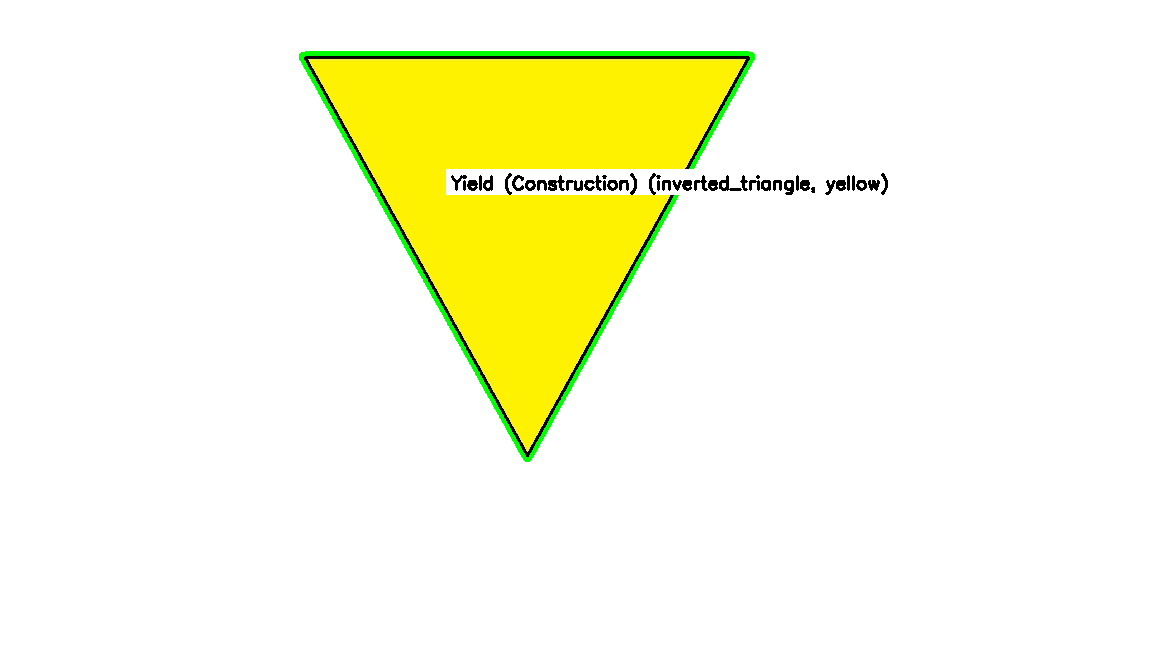

In [22]:
from google.colab import drive
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import imutils

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Path to the image in Google Drive
image_path = '/content/drive/MyDrive/SI/imagenes/figuras/trianguloinverso_amarillo.jpg'

# Load the image
img_original = cv2.imread(image_path)

# Check if the image was loaded correctly
if img_original is None:
    print(f"Error: Could not load the image from path: {image_path}")
    print("Please check that the path is correct and the file exists.")
else:
    # Copy the original image to draw results
    img_result = img_original.copy()

    # Convert to grayscale
    img_gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur to reduce noise
    img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # Edge detection
    edges = cv2.Canny(img_blur, 50, 150)

    # Morphological operations to clean edges
    structure = np.ones((3, 3), np.uint8)
    edges = cv2.dilate(edges, structure, iterations=1)
    edges = cv2.erode(edges, structure, iterations=1)

    # Find contours
    contours = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(contours)

    # Function to check if a triangle is inverted
    def is_inverted_triangle(approx_points):
        pts = approx_points.reshape(3, 2)
        pts = pts[pts[:, 1].argsort()]  # sort by Y coordinate
        top_diff = abs(pts[1, 1] - pts[0, 1])
        bottom_diff = abs(pts[2, 1] - pts[1, 1])
        return bottom_diff > top_diff

    # Function to detect the geometric shape
    def detect_shape(cnt):
        detected_shape = "unknown"
        perimeter = cv2.arcLength(cnt, True)
        area_cnt = cv2.contourArea(cnt)

        circularity = 4 * np.pi * area_cnt / (perimeter * perimeter) if perimeter > 0 else 0

        approx_fine = cv2.approxPolyDP(cnt, 0.015 * perimeter, True)
        approx_mid = cv2.approxPolyDP(cnt, 0.03 * perimeter, True)
        approx_coarse = cv2.approxPolyDP(cnt, 0.04 * perimeter, True)

        fine_vertices = len(approx_fine)
        mid_vertices = len(approx_mid)
        coarse_vertices = len(approx_coarse)

        print(f"  Vertices: fine={fine_vertices}, mid={mid_vertices}, coarse={coarse_vertices}")
        print(f"  Circularity: {circularity:.3f}")

        (x, y, w, h) = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)

        if coarse_vertices == 3:
            detected_shape = "inverted_triangle" if is_inverted_triangle(approx_coarse) else "triangle"
        elif coarse_vertices == 4:
            detected_shape = "square" if 0.95 <= aspect_ratio <= 1.05 else "rectangle"
        elif 6 <= fine_vertices <= 10 and circularity < 0.88:
            if 0.85 <= aspect_ratio <= 1.15:
                detected_shape = "octagon"
        elif circularity > 0.88 or fine_vertices > 10:
            detected_shape = "circle"
        elif mid_vertices == 8 and 0.85 <= aspect_ratio <= 1.15:
            detected_shape = "octagon"
        elif circularity > 0.80:
            detected_shape = "circle"

        return detected_shape

    # Function to detect the predominant border color
    def detect_border_color(img, cnt):
        mask = np.zeros(img.shape[:2], dtype="uint8")
        cv2.drawContours(mask, [cnt], -1, 255, thickness=-1)

        kernel_color = np.ones((15, 15), np.uint8)
        mask_inner = cv2.erode(mask, kernel_color, iterations=2)

        img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hsv_mean = cv2.mean(img_hsv, mask=mask_inner)[:3]

        print(f"  Mean HSV: H={hsv_mean[0]:.1f}, S={hsv_mean[1]:.1f}, V={hsv_mean[2]:.1f}")

        detected_color = "unknown"
        if (hsv_mean[0] < 15 or hsv_mean[0] > 155) and hsv_mean[1] > 100:
            detected_color = "red"
        elif 90 < hsv_mean[0] < 130 and hsv_mean[1] > 100:
            detected_color = "blue"
        elif 20 < hsv_mean[0] < 40 and hsv_mean[1] > 100:
            detected_color = "yellow"

        return detected_color

    print("Analyzing traffic signs...\n")

    for idx, cnt in enumerate(contours):
        detected_area = cv2.contourArea(cnt)
        if detected_area < 5000:
            continue

        print(f"Sign #{idx + 1}:")
        shape_detected = detect_shape(cnt)
        color_detected = detect_border_color(img_original, cnt)

        print(f"  Result: Shape={shape_detected}, Color={color_detected}")

        sign_type = "Unknown Sign"

        # BLUE signs
        if color_detected == "blue":
            if shape_detected == "circle":
                sign_type = "Recommendation"
            elif shape_detected == "square":
                sign_type = "Speed Recommendation"

        # RED signs
        elif color_detected == "red":
            if shape_detected == "circle":
                sign_type = "Prohibited"
            elif shape_detected == "octagon":
                sign_type = "Stop"
            elif shape_detected == "triangle":
                sign_type = "Danger"
            elif shape_detected == "inverted_triangle":
                sign_type = "Yield"

        # YELLOW signs (construction)
        elif color_detected == "yellow":
            if shape_detected == "circle":
                sign_type = "Prohibited (Construction)"
            elif shape_detected == "square":
                sign_type = "Priority Road"
            elif shape_detected == "octagon":
                sign_type = "Stop (Construction)"
            elif shape_detected == "triangle":
                sign_type = "Danger (Construction)"
            elif shape_detected == "inverted_triangle":
                sign_type = "Yield (Construction)"

        print(f"  Classification: {sign_type}\n")

        if "Unknown" not in sign_type:
            cv2.drawContours(img_result, [cnt], -1, (0, 255, 0), 3)
            moments = cv2.moments(cnt)
            if moments["m00"] != 0:
                center_x = int(moments["m10"] / moments["m00"])
                center_y = int(moments["m01"] / moments["m00"])
            else:
                center_x, center_y = 0, 0

            text = f"{sign_type} ({shape_detected}, {color_detected})"
            (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img_result, (center_x - 80, center_y - 20),
                          (center_x - 80 + text_w + 10, center_y + 5), (255, 255, 255), -1)
            cv2.putText(img_result, text, (center_x - 75, center_y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    print("=" * 50)
    print("Final result:")
    cv2_imshow(img_result)


### 🧾 Memoria explicativa del proyecto: Detección de señales de tráfico por forma y color

Se ha creado en este proyecto un sistema simple de **visión por computadora** que puede **identificar y clasificar señales de tránsito** dependiendo de su **forma geométrica** y su **color predominante**.  
Se empleó la biblioteca **NumPy** para realizar operaciones numéricas y la biblioteca **OpenCV** para procesar imágenes.


Primero, se sube la imagen desde Google Drive y se le aplica un procedimiento de **preprocesado**. Este procedimiento comprende convertirla a escala de grises, aplicar un **suavizado Gaussiano** y detectar los bordes por medio del algoritmo de *Canny*.    

Los contornos de los objetos detectados se **extraen a continuación**, y se examinan atributos como el número de vértices, la circularidad y la relación de aspecto para establecer su forma (triángulo, cuadrado, círculo, octágono, etc.).

Cuando se ha determinado la forma, se estima el **color principal del interior** de la figura en el espacio de color *HSV*, lo que posibilita categorizar la señal como **amarilla**, **roja** o **azul**.  
Al final, el programa indica sobre la imagen original el tipo de señal que detectó, fusionando la información de color y forma (como *Ceda el paso*, *Peligro*, *Stop*, *Recomendación*, entre otras).

---
